In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [23]:
# Import libraries
import warnings
import pandas as pd
import sys; sys.path.insert(0, '..')

from varclushi import VarClusHi
from varclushi_opt import VarClusHi_Opt
from src.benchmark_test import load_data, check_correctness, benchmark_times, plot_time, benchmark_scaling, plot_scaling, run_cprofile

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)

In [3]:
# Data for test (Same as demo)
df_demo = load_data(make = False)

# Show table
df_demo.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [4]:
# Check correctness
check_correctness(
    orig_cls = VarClusHi,
    opt_cls = VarClusHi_Opt,
    df = df_demo
)


────────────────────────────────────────────────────────────
  CORRECTNESS CHECK
────────────────────────────────────────────────────────────
  ✓ PASS  N clusters match
  ✓ PASS  N_Vars match
  ✓ PASS  Eigval1 close
  ✓ PASS  Eigval2 close
  ✓ PASS  RS_Own close
  ✓ PASS  RS_NC close
  ✓ PASS  RS_Ratio close

  All checks passed — outputs are numerically identical.

DONE


In [5]:
# Make huge data (Limit at 20k rows and 200 features)
df_big = load_data(n_obs = 20000, n_vars = 200, n_groups = 4)

# Show table
df_big.head(5)

,g0_v0,g0_v1,g0_v2,g0_v3,g0_v4,g0_v5,g0_v6,g0_v7,g0_v8,g0_v9,...,g3_v40,g3_v41,g3_v42,g3_v43,g3_v44,g3_v45,g3_v46,g3_v47,g3_v48,g3_v49
0,0.844632,0.449649,-0.249621,-0.111047,-0.261858,-0.516574,0.486962,-0.737189,0.411638,-0.078347,...,1.001189,-1.531281,0.543192,-1.004692,-0.647820,0.800711,-0.902068,0.109063,0.231657,-0.636979
1,-0.778105,-0.657177,-1.749114,-0.943001,-1.233674,-1.475398,-0.597539,-0.626202,-1.298592,-1.484913,...,0.671244,-0.065049,1.326549,-0.944406,1.026186,0.024800,1.200567,0.625191,1.062752,0.000906
2,0.108777,-0.965275,-0.332377,-0.044177,0.669777,0.477081,0.040376,1.067553,1.562726,1.154082,...,-1.038860,-1.105299,-0.066675,0.367645,0.437262,0.067621,-1.166369,0.214470,-0.280979,0.233814
3,0.489778,-0.197778,1.213871,2.491297,0.428441,1.231557,0.472179,2.502275,-0.754463,0.813426,...,0.485224,-0.102958,-0.642864,1.750904,-1.691390,-0.054024,-0.885769,-1.727139,-1.358574,-1.000708
4,-0.651632,-1.255003,-2.034374,-0.024651,-1.449683,-0.174067,-0.719611,-1.100106,-1.675511,-1.995124,...,0.413062,0.698330,-1.111462,-1.008371,-0.663348,-0.971731,-0.570555,0.119533,-0.610301,-1.200349


In [10]:
# Run cProfiler on original version
run_cprofile(
    cls = VarClusHi,
    df = df_big,
    label = "Original"
)


────────────────────────────────────────────────────────────
  cPROFILE — Original
────────────────────────────────────────────────────────────
  ncalls  tottime  percall  cumtime  function
    3266    0.004    0.000    0.006  _handle_fromlist
     218    0.000    0.000    0.001  simplefilter
      13    0.000    0.000    0.000  __call__
       4    0.000    0.000    0.000  dumps
       1    0.000    0.000    0.000  __subclasscheck__
     654    0.000    0.000    0.000  __enter__
     654    0.000    0.000    0.000  __exit__
       2    0.000    0.000    0.000  _type_convert
     218    0.000    0.000    0.000  _get_context
     218    0.000    0.000    0.001  __enter__
     218    0.000    0.000    0.000  __exit__
       1    0.000    0.000    0.000  namedtuple
       1    0.000    0.000    0.000  __exit__
      13    0.000    0.000    0.000  __new__
       6    0.000    0.000    0.000  <genexpr>


In [11]:
# Run cProfiler on optimized version
run_cprofile(
    cls = VarClusHi_Opt,
    df = df_big,
    label = "Optimized"
)


────────────────────────────────────────────────────────────
  cPROFILE — Optimized
────────────────────────────────────────────────────────────
  ncalls  tottime  percall  cumtime  function
      18    0.000    0.000    0.000  _handle_fromlist
     222    0.000    0.000    0.001  simplefilter
      13    0.000    0.000    0.000  __call__
       4    0.000    0.000    0.000  dumps
       1    0.000    0.000    0.000  __subclasscheck__
     666    0.000    0.000    0.000  __enter__
     666    0.000    0.000    0.000  __exit__
       2    0.000    0.000    0.000  _type_convert
     222    0.000    0.000    0.000  _get_context
     222    0.000    0.000    0.001  __enter__
     222    0.000    0.000    0.001  __exit__
       1    0.000    0.000    0.000  namedtuple
       1    0.000    0.000    0.000  __exit__
      13    0.000    0.000    0.000  __new__
       6    0.000    0.000    0.000  <genexpr>


In [18]:
# Run time testing
N_RUNS = 200

runtimes_results = benchmark_times(
    orig_cls = VarClusHi,
    opt_cls = VarClusHi_Opt,
    df = df_demo,
    n_runs = N_RUNS
)


────────────────────────────────────────────────────────────
  TIMING BENCHMARK BY RUN 200 TIMES
────────────────────────────────────────────────────────────

▶ Original
  mean       0.0533s ± 0.0059s          
  min        0.0469s
  max        0.1093s

▶ Optimized
  mean       0.0141s ± 0.0012s          
  min        0.0122s
  max        0.0209s

────────────────────────────────────────────────────────────
  SUMMARY
────────────────────────────────────────────────────────────
          Mean (s) Std (s) Min (s) Max (s)
Version                                   
Original    0.0533  0.0059  0.0469  0.1093
Optimized   0.0141  0.0012  0.0122  0.0209

  Speedup: 3.79x


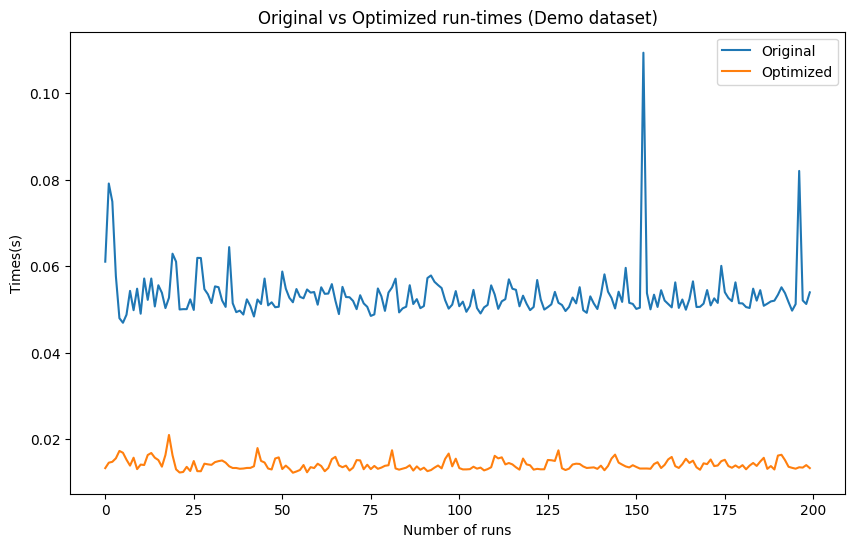

In [19]:
# Plot
plot_time(
    runtimes_results,
    title = "Original vs Optimized run-times (Demo dataset)"
)

In [20]:
# Run time testing
N_RUNS = 5

runtimes_big_results = benchmark_times(
    orig_cls = VarClusHi,
    opt_cls = VarClusHi_Opt,
    df = df_big,
    n_runs = N_RUNS
)


────────────────────────────────────────────────────────────
  TIMING BENCHMARK BY RUN 5 TIMES
────────────────────────────────────────────────────────────

▶ Original
  mean       14.8464s ± 0.9600s         
  min        13.5937s
  max        16.4938s

▶ Optimized
  mean       1.4380s ± 0.6753s          
  min        0.8294s
  max        2.3690s

────────────────────────────────────────────────────────────
  SUMMARY
────────────────────────────────────────────────────────────
          Mean (s) Std (s)  Min (s)  Max (s)
Version                                     
Original   14.8464  0.9600  13.5937  16.4938
Optimized   1.4380  0.6753   0.8294   2.3690

  Speedup: 10.32x


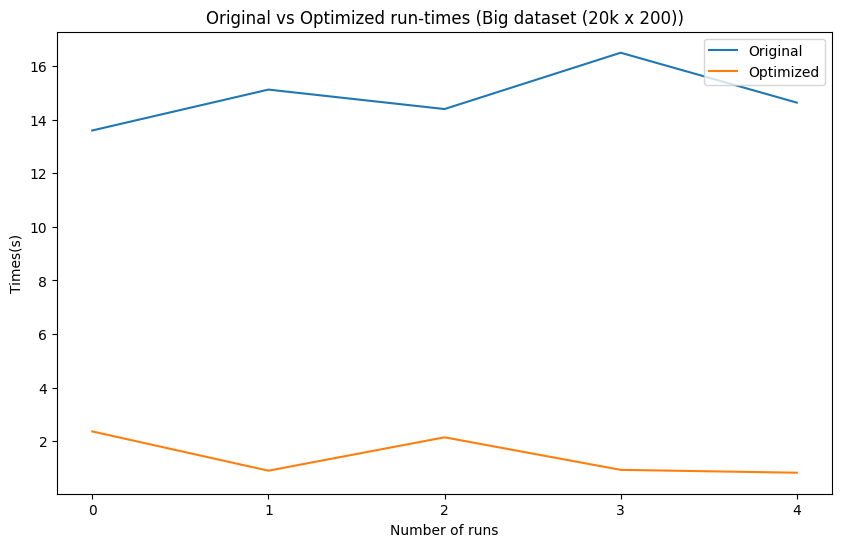

In [21]:
# Plot
plot_time(
    runtimes_big_results,
    title = "Original vs Optimized run-times (Big dataset (20k x 200))"
)

In [22]:
# Test on accumulate dataset 
N_RUNS = 5
SIZES = [50_000, 500_000, 1_000_000]
VARS = [100, 150, 200]

runtimes_scale_results = benchmark_scaling(
    VarClusHi_Opt,
    dataset_sizes = SIZES,
    n_runs = N_RUNS,
    n_vars = VARS,
    n_groups = 4
)


────────────────────────────────────────────────────────────
  SCALING BENCHMARK (5 runs per size)
────────────────────────────────────────────────────────────

▶ Data size: 50000, Features: 100
  mean       0.1914s ± 0.0101s          
  min        0.1732s
  max        0.2020s

▶ Data size: 50000, Features: 150
  mean       0.9047s ± 0.3507s          
  min        0.3682s
  max        1.4711s

▶ Data size: 50000, Features: 200
  mean       1.5565s ± 0.4828s          
  min        0.8359s
  max        2.3473s

▶ Data size: 500000, Features: 100
  mean       1.4523s ± 0.1825s          
  min        1.2335s
  max        1.6914s

▶ Data size: 500000, Features: 150
  mean       3.1839s ± 0.1799s          
  min        2.8887s
  max        3.4096s

▶ Data size: 500000, Features: 200
  mean       14.6079s ± 14.5148s        
  min        5.8391s
  max        43.4754s

▶ Data size: 1000000, Features: 100
  mean       3.1791s ± 0.1345s          
  min        2.9873s
  max        3.3308s

▶ Data

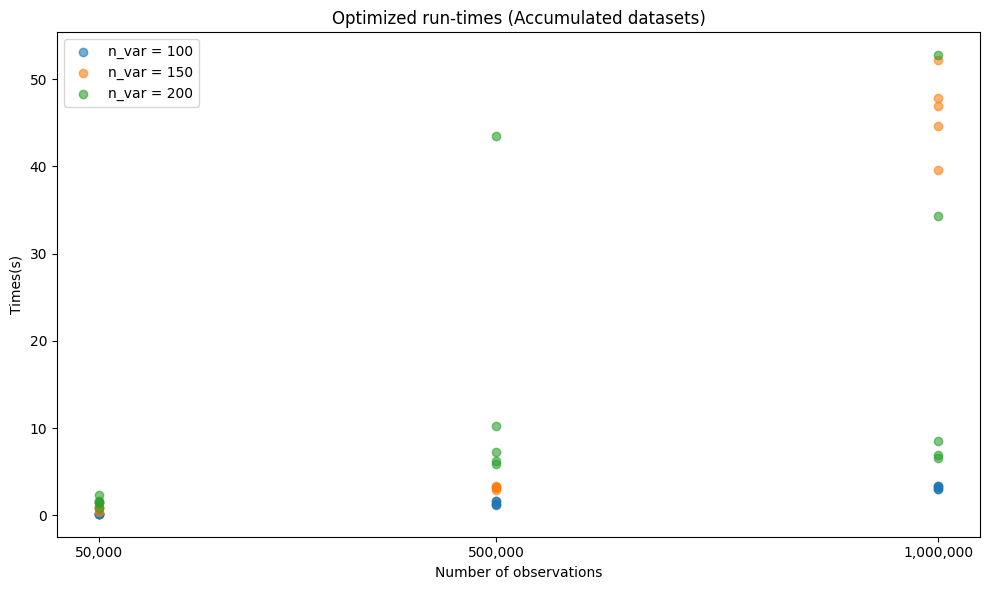

In [25]:
# Plot
plot_scaling(
    runtimes_scale_results,
    title = "Optimized run-times (Accumulated datasets)"
)